In [ ]:
!pip install noisereduce --quiet

In [ ]:
# CELL 2 — Download & extract CREMA-D
from google.colab import files

uploaded = files.upload()
for fn in uploaded.keys():
    print(f"File {fn} was uploaded")

!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ejlok1/cremad

from zipfile import ZipFile
file_path = "/content/cremad.zip"
with ZipFile(file_path, 'r') as zip_file:
    zip_file.extractall()
    print('Extraction Completed')

Saving kaggle.json to kaggle.json
File kaggle.json was uploaded
Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
100% 451M/451M [00:25<00:00, 18.8MB/s]

Extraction Completed


In [ ]:
# CELL 3 — Collect audio files + build dataframe

import os
import pandas as pd

audio_files = []
for root, dirs, files_list in os.walk("/content"):
    for file in files_list:
        if file.lower().endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print(f"Total WAV files found: {len(audio_files)}")

records = []
for fp in audio_files:
    filename = os.path.basename(fp)
    name = os.path.splitext(filename)[0]
    parts = name.split("_")
    if len(parts) == 4:
        records.append({
            "file_path": fp,
            "filename": filename,
            "actor_id": parts[0],
            "sentence": parts[1],
            "emotion": parts[2],
            "intensity": parts[3]
        })

df = pd.DataFrame(records)

emotion_mapping = {
    "ANG": "Angry", "DIS": "Disgust", "FEA": "Fear",
    "HAP": "Happy", "NEU": "Neutral", "SAD": "Sad"
}
df["emotion_label"] = df["emotion"].map(emotion_mapping)

print("Dataset shape:", df.shape)
print(df["emotion_label"].value_counts())

Total WAV files found: 7442
Dataset shape: (7442, 7)
emotion_label
Angry      1271
Disgust    1271
Happy      1271
Fear       1271
Sad        1271
Neutral    1087
Name: count, dtype: int64


In [ ]:
# CELL 4 — Actor-independent train/val/test split

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss.split(df, y=df["emotion_label"], groups=df["actor_id"]))
train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(temp_df, y=temp_df["emotion_label"], groups=temp_df["actor_id"]))
val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

df["split"] = "unused"
df.loc[train_df.index, "split"] = "train"
df.loc[val_df.index, "split"] = "validation"
df.loc[test_df.index, "split"] = "test"

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

train_actors = set(train_df["actor_id"])
val_actors = set(val_df["actor_id"])
test_actors = set(test_df["actor_id"])
print("Actor leakage check — Train∩Val:", train_actors & val_actors,
      "| Train∩Test:", train_actors & test_actors,
      "| Val∩Test:", val_actors & test_actors)

print("\nTrain emotion distribution:\n", train_df["emotion_label"].value_counts(normalize=True).round(3))
print("\nValidation emotion distribution:\n", val_df["emotion_label"].value_counts(normalize=True).round(3))
print("\nTest emotion distribution:\n", test_df["emotion_label"].value_counts(normalize=True).round(3))

Train: 5152 | Val: 1142 | Test: 1148
Actor leakage check — Train∩Val: set() | Train∩Test: set() | Val∩Test: set()

Train emotion distribution:
 emotion_label
Angry      0.171
Disgust    0.171
Happy      0.171
Fear       0.171
Sad        0.171
Neutral    0.146
Name: proportion, dtype: float64

Validation emotion distribution:
 emotion_label
Happy      0.171
Fear       0.171
Sad        0.171
Angry      0.171
Disgust    0.171
Neutral    0.146
Name: proportion, dtype: float64

Test emotion distribution:
 emotion_label
Happy      0.171
Disgust    0.171
Sad        0.171
Angry      0.171
Fear       0.171
Neutral    0.146
Name: proportion, dtype: float64


In [ ]:
# CELL 5 — Audio preprocessing (trim -> denoise, with fixed N_FRAMES)

import librosa
import numpy as np
import noisereduce as nr

SAMPLE_RATE = 16000
DURATION = 3.5
MAX_SAMPLES = int(SAMPLE_RATE * DURATION)
TRIM_TOP_DB = 25
PROP_DECREASE = 0.7

N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512


_dummy = np.zeros(MAX_SAMPLES, dtype=np.float32)
_dummy_mel = librosa.feature.melspectrogram(
    y=_dummy, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
)
N_FRAMES = _dummy_mel.shape[1]
print("Computed N_FRAMES:", N_FRAMES)


def load_and_preprocess_audio(file_path, denoise=True):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)


    trimmed, _ = librosa.effects.trim(audio, top_db=TRIM_TOP_DB)
    if len(trimmed) == 0:
        trimmed = audio

    if denoise:
        try:
            denoised = nr.reduce_noise(
                y=trimmed, sr=SAMPLE_RATE, stationary=False,
                prop_decrease=PROP_DECREASE
            )
            if np.isfinite(denoised).all():
                trimmed = denoised
            # else: keep the undenoised `trimmed` audio as-is
        except Exception:
            pass  # keep the undenoised `trimmed` audio as-is

    trimmed = np.nan_to_num(trimmed, nan=0.0, posinf=0.0, neginf=0.0)

    if len(trimmed) > MAX_SAMPLES:
        trimmed = trimmed[:MAX_SAMPLES]
    elif len(trimmed) < MAX_SAMPLES:
        trimmed = np.pad(trimmed, (0, MAX_SAMPLES - len(trimmed)), mode="constant")

    return trimmed


sample_path = train_df.iloc[0]["file_path"]
audio = load_and_preprocess_audio(sample_path)
print("Audio shape:", audio.shape, "| Expected:", (MAX_SAMPLES,))
print("Non-zero fraction:", np.mean(audio != 0))

from IPython.display import Audio, display
display(Audio(audio, rate=SAMPLE_RATE))

Computed N_FRAMES: 110
Audio shape: (56000,) | Expected: (56000,)
Non-zero fraction: 0.6034285714285714


In [ ]:
# CELL — Play 3 audio examples from each emotion


from IPython.display import Audio, display

emotions = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad"]

for emotion in emotions:
    print("\n" + "=" * 50)
    print(f"{emotion} — 3 examples")
    print("=" * 50)

    emotion_df = df[df["emotion_label"] == emotion]

    # Pick 3 different audio files from this emotion
    samples = emotion_df.sample(n=3, random_state=42)

    for i, (_, row) in enumerate(samples.iterrows(), start=1):
        print(f"\nExample {i}: {row['filename']}")
        print(f"Actor: {row['actor_id']} | Intensity: {row['intensity']}")

        audio = load_and_preprocess_audio(row["file_path"])
        display(Audio(audio, rate=SAMPLE_RATE))


Angry — 3 examples

Example 1: 1038_IOM_ANG_XX.wav
Actor: 1038 | Intensity: XX



Example 2: 1066_IEO_ANG_MD.wav
Actor: 1066 | Intensity: MD



Example 3: 1047_ITS_ANG_XX.wav
Actor: 1047 | Intensity: XX



Disgust — 3 examples

Example 1: 1072_IOM_DIS_XX.wav
Actor: 1072 | Intensity: XX



Example 2: 1004_IWL_DIS_XX.wav
Actor: 1004 | Intensity: XX


...


Example 2: 1025_ITH_NEU_XX.wav
Actor: 1025 | Intensity: XX



Example 3: 1070_ITH_NEU_XX.wav
Actor: 1070 | Intensity: XX



Sad — 3 examples

Example 1: 1011_DFA_SAD_XX.wav
Actor: 1011 | Intensity: XX



Example 2: 1085_IEO_SAD_MD.wav
Actor: 1085 | Intensity: MD



Example 3: 1060_ITS_SAD_XX.wav
Actor: 1060 | Intensity: XX


Spectrogram shape: (128, 110)


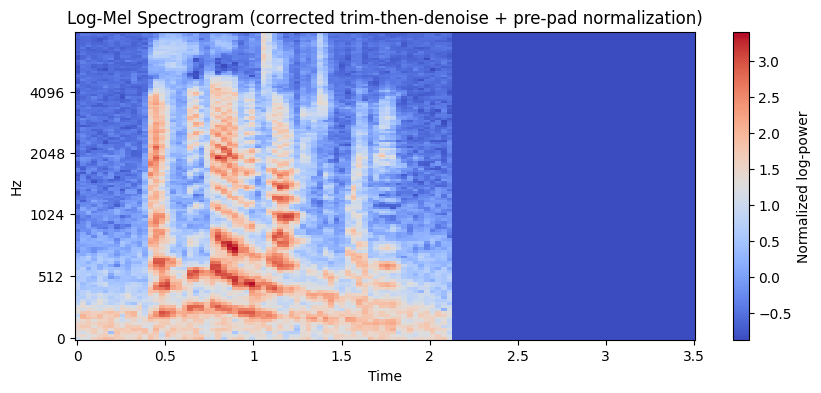

In [ ]:
# CELL 6 — Log-mel spectrogram extraction (normalize BEFORE padding)

def extract_log_mel(file_path):
    """Fixed-shape (N_MELS, N_FRAMES) log-mel spectrogram, per-clip normalized."""
    audio = load_and_preprocess_audio(file_path)

    mel = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)

    mean = log_mel.mean()
    std = log_mel.std() + 1e-8

    if log_mel.shape[1] < N_FRAMES:
        pad_width = N_FRAMES - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode="constant",
                          constant_values=log_mel.min())
    elif log_mel.shape[1] > N_FRAMES:
        log_mel = log_mel[:, :N_FRAMES]

    log_mel = (log_mel - mean) / std
    return log_mel.astype(np.float32)


sample_spec = extract_log_mel(sample_path)
print("Spectrogram shape:", sample_spec.shape)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
librosa.display.specshow(sample_spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                          x_axis="time", y_axis="mel")
plt.colorbar(label="Normalized log-power")
plt.title("Log-Mel Spectrogram (corrected trim-then-denoise + pre-pad normalization)")
plt.show()

In [ ]:
# CELL 7 — Build spectrogram datasets for train/val/test

from tqdm.auto import tqdm

def build_spectrogram_dataset(dataframe):
    specs, labels = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        specs.append(extract_log_mel(row["file_path"]))
        labels.append(row["emotion_label"])
    X = np.array(specs)[..., np.newaxis]
    y = np.array(labels)
    return X, y

print("Building training spectrograms...")
X_train_spec, y_train_spec = build_spectrogram_dataset(train_df)
print("Train shape:", X_train_spec.shape)

print("Building validation spectrograms...")
X_val_spec, y_val_spec = build_spectrogram_dataset(val_df)
print("Val shape:", X_val_spec.shape)

print("Building test spectrograms...")
X_test_spec, y_test_spec = build_spectrogram_dataset(test_df)
print("Test shape:", X_test_spec.shape)

os.makedirs("/content/spec_features", exist_ok=True)
np.save("/content/spec_features/X_train.npy", X_train_spec)
np.save("/content/spec_features/X_val.npy", X_val_spec)
np.save("/content/spec_features/X_test.npy", X_test_spec)
np.save("/content/spec_features/y_train.npy", y_train_spec)
np.save("/content/spec_features/y_val.npy", y_val_spec)
np.save("/content/spec_features/y_test.npy", y_test_spec)
print("Spectrograms cached to /content/spec_features/")

Building training spectrograms...


  0%|          | 0/5152 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/noisereduce/spectralgate/nonstationary.py:70: RuntimeWarning: invalid value encountered in divide
  sig_mult_above_thresh = (abs_sig_stft - sig_stft_smooth) / sig_stft_smooth


Train shape: (5152, 128, 110, 1)
Building validation spectrograms...


  0%|          | 0/1142 [00:00<?, ?it/s]

Val shape: (1142, 128, 110, 1)
Building test spectrograms...


  0%|          | 0/1148 [00:00<?, ?it/s]

Test shape: (1148, 128, 110, 1)
Spectrograms cached to /content/spec_features/


In [ ]:
# CELL 8 — Label encoding + class weights

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

label_encoder = LabelEncoder()
label_encoder.fit(y_train_spec)

y_train_enc = label_encoder.transform(y_train_spec)
y_val_enc = label_encoder.transform(y_val_spec)
y_test_enc = label_encoder.transform(y_test_spec)

num_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

y_train_cat = tf.keras.utils.to_categorical(y_train_enc, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val_enc, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test_enc, num_classes)


sample_weights_train = np.array(
    [class_weight_dict[label] for label in y_train_enc], dtype=np.float32
)

Classes: [np.str_('Angry'), np.str_('Disgust'), np.str_('Fear'), np.str_('Happy'), np.str_('Neutral'), np.str_('Sad')]
Class weights: {0: np.float64(0.9757575757575757), 1: np.float64(0.9757575757575757), 2: np.float64(0.9757575757575757), 3: np.float64(0.9757575757575757), 4: np.float64(1.1418439716312057), 5: np.float64(0.9757575757575757)}


In [ ]:
# CELL 9 — SpecAugment-style augmentation (train set only)

def spec_augment(spec, label, weight, freq_mask_pct=0.15, time_mask_pct=0.15):
    spec = tf.identity(spec)
    n_mels = tf.shape(spec)[0]
    n_frames = tf.shape(spec)[1]

    f = tf.random.uniform([], 0, tf.cast(tf.cast(n_mels, tf.float32) * freq_mask_pct, tf.int32) + 1, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, n_mels - f + 1, dtype=tf.int32)
    freq_mask = tf.concat([
        tf.ones([f0, n_frames, 1]),
        tf.zeros([f, n_frames, 1]),
        tf.ones([n_mels - f0 - f, n_frames, 1])
    ], axis=0)

    t = tf.random.uniform([], 0, tf.cast(tf.cast(n_frames, tf.float32) * time_mask_pct, tf.int32) + 1, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, n_frames - t + 1, dtype=tf.int32)
    time_mask = tf.concat([
        tf.ones([n_mels, t0, 1]),
        tf.zeros([n_mels, t, 1]),
        tf.ones([n_mels, n_frames - t0 - t, 1])
    ], axis=1)

    spec = spec * freq_mask * time_mask
    return spec, label, weight


BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train_spec, y_train_cat, sample_weights_train))
train_ds = train_ds.shuffle(1000).map(spec_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_spec, y_val_cat)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_spec, y_test_cat)).batch(BATCH_SIZE)

In [ ]:
# CELL 10 — CNN model

from tensorflow.keras import layers, models

input_shape = X_train_spec.shape[1:]  # (N_MELS, N_FRAMES, 1)

def build_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)


cnn_model = build_cnn(input_shape, num_classes)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 110, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 110, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 110, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 55, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,950 (1011.52 KB)

 Trainable params: 258,246 (1008.77 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.3405 - loss: 1.5774 - val_accuracy: 0.1708 - val_loss: 4.8145 - learning_rate: 0.0010
Epoch 2/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3919 - loss: 1.4826 - val_accuracy: 0.2391 - val_loss: 2.1336 - learning_rate: 0.0010
Epoch 3/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4175 - loss: 1.4245 - val_accuracy: 0.2644 - val_loss: 2.0223 - learning_rate: 0.0010
Epoch 4/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4321 - loss: 1.4116 - val_accuracy: 0.3888 - val_loss: 1.4115 - learning_rate: 0.0010
Epoch 5/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4581 - loss: 1.3694 - val_accuracy: 0.3660 - val_loss: 1.5580 - learning_rate: 0.0010
Epoch 6/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4499 - loss: 1.3635 - val_accuracy: 0.4685 - val_loss: 1.3163 - learning_rate: 0.0010
Epoch 7/60
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4680 - loss: 1

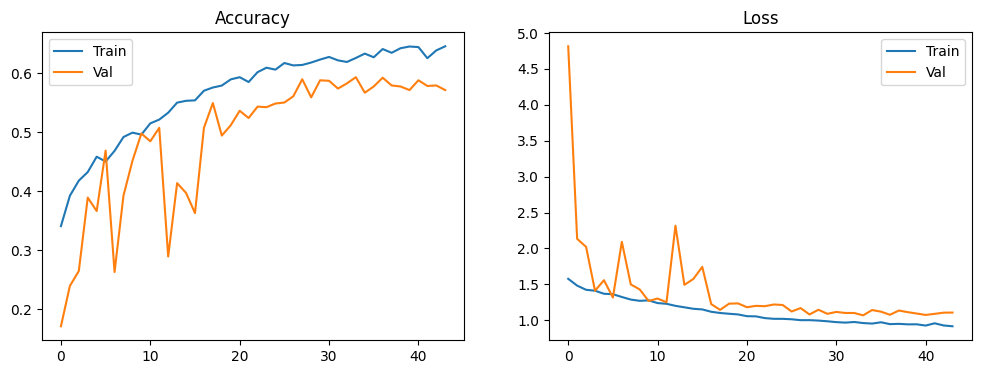

In [ ]:
# CELL 11 — Train

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6
    ),
]


history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.show()


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
===== MODEL 2 (v3): CNN + Corrected Preprocessing + Explicit Sample Weighting =====
Accuracy:  0.5601
Precision: 0.5787
Recall:    0.5601
F1-score:  0.5633

Classification Report:
              precision    recall  f1-score   support

       Angry       0.66      0.65      0.66       196
     Disgust       0.55      0.54      0.54       196
        Fear       0.49      0.47      0.48       196
       Happy       0.44      0.60      0.51       196
     Neutral       0.78      0.52      0.62       168
         Sad       0.57      0.58      0.58       196

    accuracy                           0.56      1148
   macro avg       0.58      0.56      0.56      1148
weighted avg       0.58      0.56      0.56      1148



<Figure size 800x700 with 0 Axes>

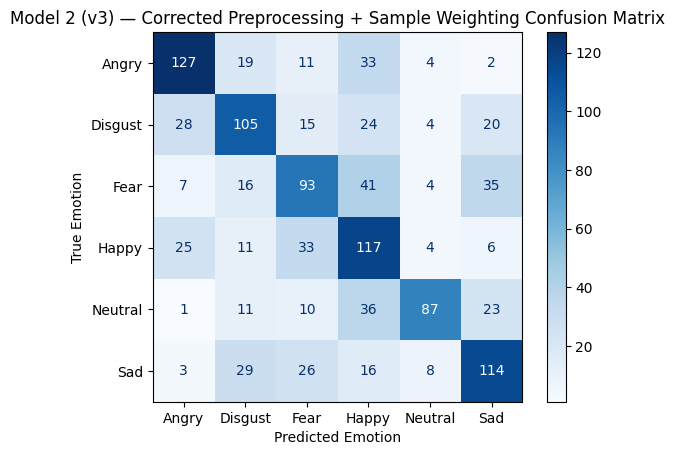

In [ ]:
# CELL 12 — Test evaluation

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

y_test_pred_probs = cnn_model.predict(test_ds)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

cnn_accuracy = accuracy_score(y_test_enc, y_test_pred)
cnn_precision = precision_score(y_test_enc, y_test_pred, average="weighted")
cnn_recall = recall_score(y_test_enc, y_test_pred, average="weighted")
cnn_f1 = f1_score(y_test_enc, y_test_pred, average="weighted")

print("===== MODEL CNN  =====")
print(f"Accuracy:  {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall:    {cnn_recall:.4f}")
print(f"F1-score:  {cnn_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test_enc, y_test_pred)
plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Model 2")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

In [ ]:
# CELL 13 — Results table

model_results = [{
    "Model": "CNN + Corrected Preprocessing + Explicit Sample Weighting",
    "Accuracy": cnn_accuracy,
    "Precision": cnn_precision,
    "Recall": cnn_recall,
    "F1-score": cnn_f1
}]
results_df = pd.DataFrame(model_results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,CNN + Corrected Preprocessing + Explicit Sampl...,0.560105,0.578671,0.560105,0.563254
